In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/LoanApprovalPrediction.csv")

In [ ]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
df.shape

(614, 13)

# Linear Regression

In [ ]:
df[["Loan_Amount_Term"]] = df[["Loan_Amount_Term"]].fillna(0)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
y = df["Loan_Amount_Term"]
x = df[["ApplicantIncome"]]
model.fit(x,y)
print(model.predict([[500]]))

[335.23399378]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Logistic Regression


In [ ]:
df.head(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(0)

In [ ]:
from sklearn.linear_model import LogisticRegression

clean_df = df.dropna(subset=['Loan_Amount_Term', 'Dependents']).copy()

clean_df['Dependents'] = clean_df['Dependents'].replace('3+', '3').astype(int)

x = clean_df[['Loan_Amount_Term']]
y = clean_df['Dependents']

model = LogisticRegression()
model.fit(x, y)

print(model.predict([[500]]))

[0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


# Decision Tree Algorithm


Accuracy: 0.8455284552845529

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.53      0.68        38
           1       0.82      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.76      0.79       123
weighted avg       0.86      0.85      0.83       123



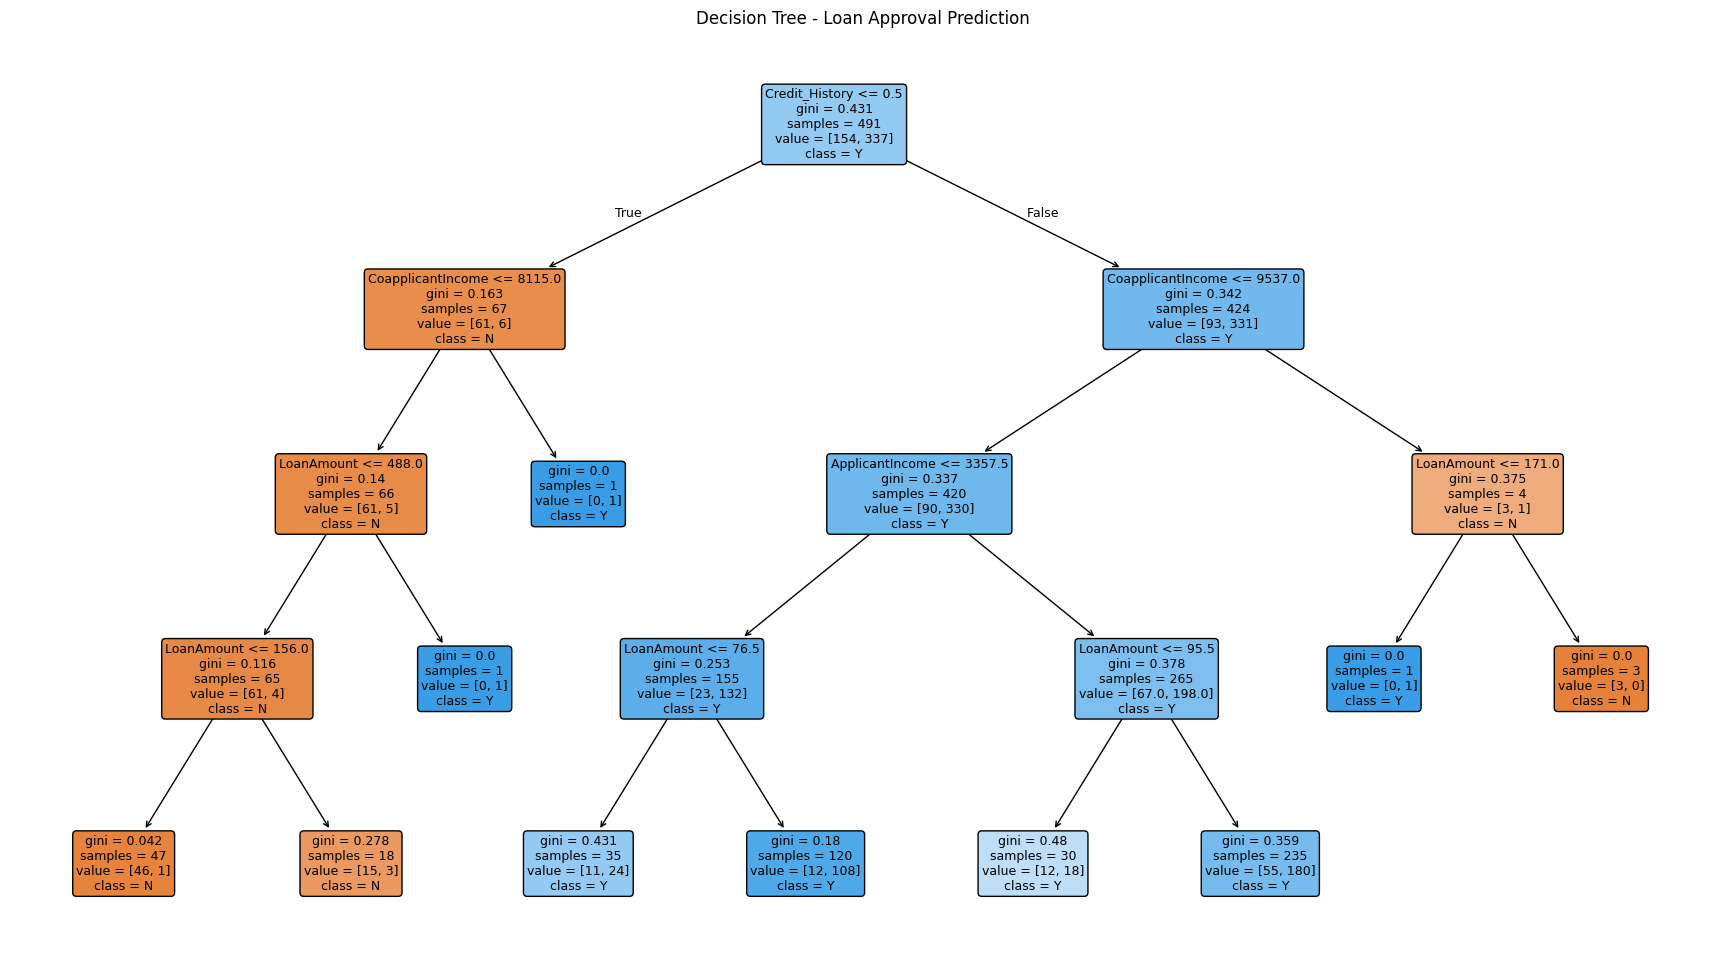

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

df_dt = df.copy()

# 2. Handle Missing Values

# Handle 'Dependents' column: replace '3+' with '3' and convert to numeric
df_dt['Dependents'] = df_dt['Dependents'].replace('3+', '3')
df_dt['Dependents'] = pd.to_numeric(df_dt['Dependents'])

# Numerical columns
num_cols = df_dt.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    df_dt[col] = df_dt[col].fillna(df_dt[col].median())

# Categorical columns
cat_cols = df_dt.select_dtypes(include=["object"]).columns

for col in cat_cols:
    df_dt[col] = df_dt[col].fillna(df_dt[col].mode()[0])

# 3. Convert Categorical Data

label_encoder = LabelEncoder()

for col in df_dt.select_dtypes(include=["object"]).columns:
    df_dt[col] = label_encoder.fit_transform(df_dt[col])

# 4. Separate Features and Target

X = df_dt.drop(["Loan_Status", "Loan_ID"], axis=1)
y = df_dt["Loan_Status"]

# 5. Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 6. Create Decision Tree Model

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# 7. Prediction

y_pred = model.predict(X_test)

# 8. Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 9. Plot Decision Tree

plt.figure(figsize=(22, 12))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["N", "Y"],  # Assuming 'N' and 'Y' are target classes
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree - Loan Approval Prediction")

plt.show()

## Random Forest Algorithm

In [ ]:
from sklearn.ensemble import RandomForestClassifier


model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
model_rf.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = model_rf.predict(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("\nRandom Forest Accuracy:", accuracy_rf)

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.8211382113821138

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.63      0.69        38
           1       0.85      0.91      0.88        85

    accuracy                           0.82       123
   macro avg       0.80      0.77      0.78       123
weighted avg       0.82      0.82      0.82       123



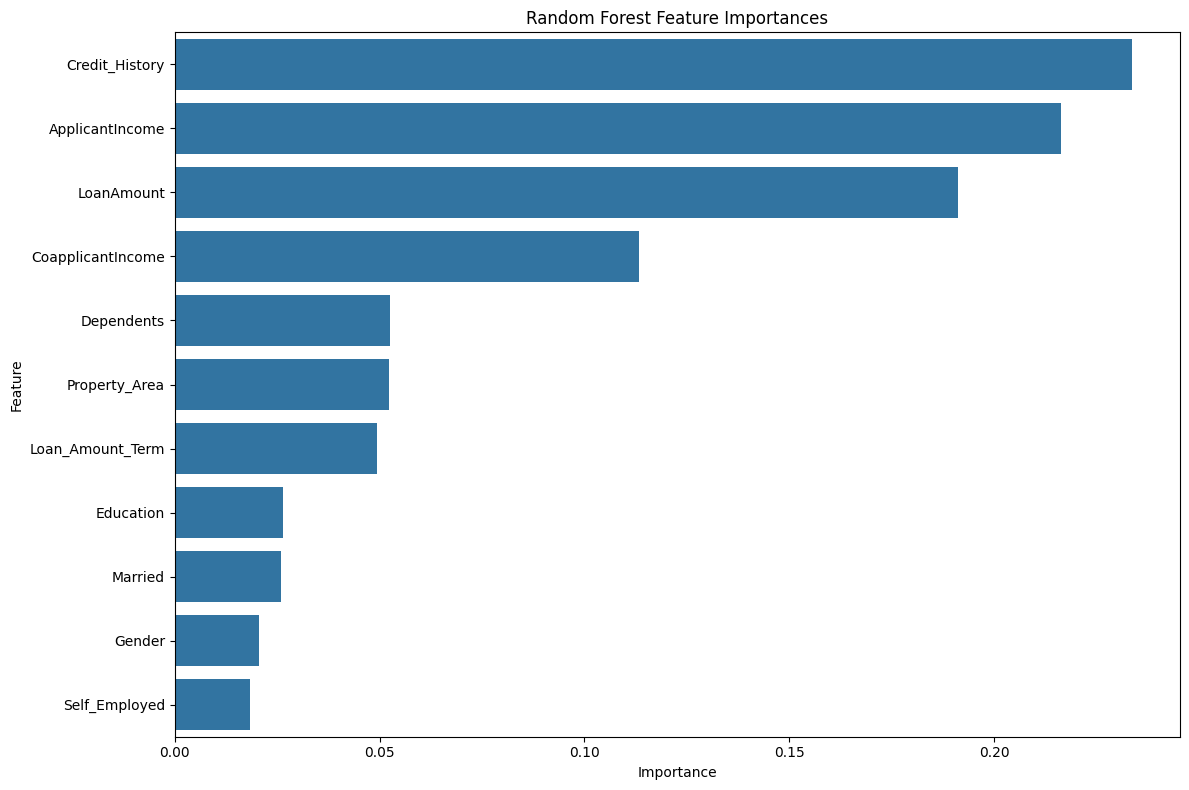

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the Random Forest model
feature_importances = model_rf.feature_importances_

# Create a pandas Series for better visualization
features_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})
features_df = features_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df)
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

# SVM

In [ ]:
from sklearn.svm import SVC

model_svm = SVC(random_state=42)

# Train the model
model_svm.fit(X_train, y_train)

# Make predictions on the test set
y_pred_svm = model_svm.predict(X_test)

# Evaluate the model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("\nSVM Accuracy:", accuracy_svm)

print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.6910569105691057

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        38
           1       0.69      1.00      0.82        85

    accuracy                           0.69       123
   macro avg       0.35      0.50      0.41       123
weighted avg       0.48      0.69      0.56       123



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


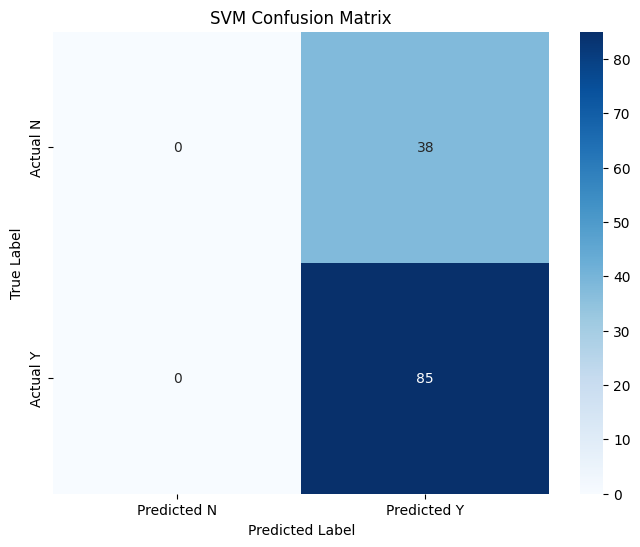

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted N', 'Predicted Y'],
            yticklabels=['Actual N', 'Actual Y'])
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize KNN model
# n_neighbors is a hyperparameter to tune. Starting with a common value like 5.
model_knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
model_knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred_knn = model_knn.predict(X_test)

# Evaluate the model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("\nKNN Accuracy:", accuracy_knn)

print("\nKNN Classification Report:")
print(classification_report(y_test, y_pred_knn))


KNN Accuracy: 0.6422764227642277

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.39      0.29      0.33        38
           1       0.72      0.80      0.76        85

    accuracy                           0.64       123
   macro avg       0.55      0.54      0.54       123
weighted avg       0.62      0.64      0.63       123



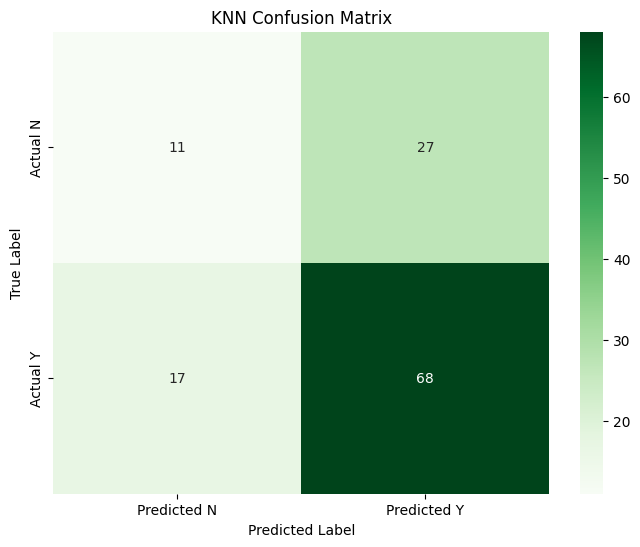

In [ ]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted N', 'Predicted Y'],
            yticklabels=['Actual N', 'Actual Y'])
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

/tmp/ipykernel_1210/3805251887.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis')


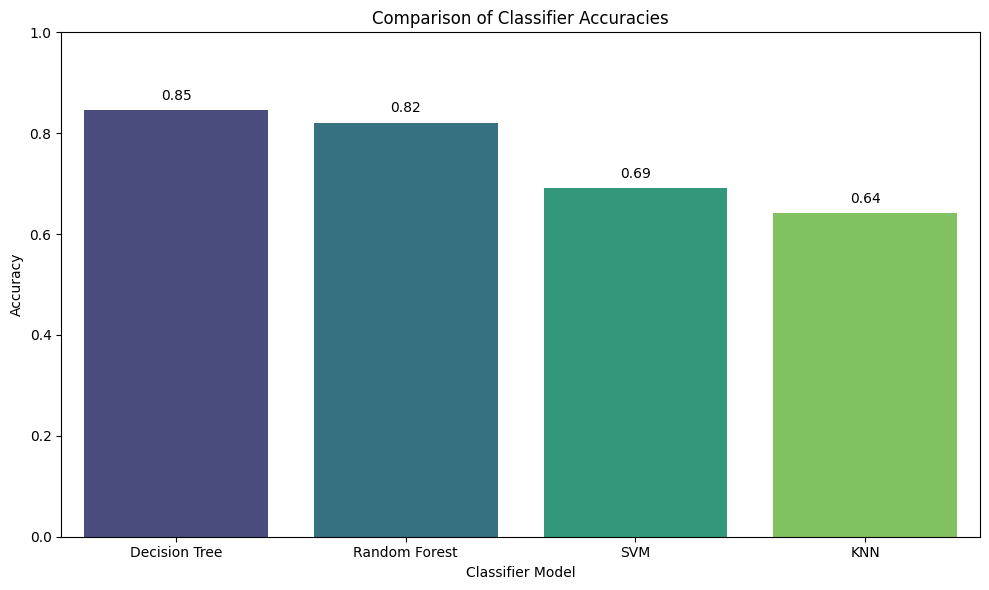

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Collect accuracy scores from each model
accuracies = {
    'Decision Tree': accuracy,
    'Random Forest': accuracy_rf,
    'SVM': accuracy_svm,
    'KNN': accuracy_knn
}

# Create a DataFrame for easy plotting
accuracy_df = pd.DataFrame(list(accuracies.items()), columns=['Model', 'Accuracy'])

# Sort by accuracy for better visualization
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False)

# Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis')
plt.title('Comparison of Classifier Accuracies')
plt.xlabel('Classifier Model')
plt.ylabel('Accuracy')
plt.ylim(0.0, 1.0) # Ensure y-axis starts at 0 and goes up to 1

# Add accuracy values on top of the bars
for index, row in accuracy_df.iterrows():
    plt.text(index, row.Accuracy + 0.02, f'{row.Accuracy:.2f}', color='black', ha="center")

plt.tight_layout()
plt.show()

This plot visually represents the performance of each model based on its accuracy score. As observed previously, the Decision Tree Classifier achieved the highest accuracy, while KNN and SVM (with default parameters) performed less effectively on this dataset.